##### Import Root & Opening Files

In [2]:
import ROOT

ROOT.gStyle.SetOptStat(0)

ggF_f = ROOT.TFile("PPSSP_2026/1l2tau/run2/signal_ggF.root") # Gluon-Gluon Fusion
VBF_f = ROOT.TFile("PPSSP_2026/1l2tau/run2/signal_VBF.root") # Vector Boson Fusion


ggF_f.ls()
VBF_f.ls()

TFile**		PPSSP_2026/1l2tau/run2/signal_ggF.root	
 TFile*		PPSSP_2026/1l2tau/run2/signal_ggF.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree
TFile**		PPSSP_2026/1l2tau/run2/signal_VBF.root	
 TFile*		PPSSP_2026/1l2tau/run2/signal_VBF.root	
  KEY: TTree	AnalysisMiniTree;1	AnalysisMiniTree


/home/est3ban3/IFJ_PAN_PROJECT/MVA-Project/venv/lib/python3.14/site-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


In [3]:
ggF_tree = ggF_f.Get("AnalysisMiniTree")
ggF_tree.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :   133971 : Total =        71251418 bytes  File  Size =   32164787 *
*        :          : Tree compression factor =   2.21                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :   133971 : Total  Size=     539584 bytes  File Size  =       6445 *
*Baskets :       33 : Basket Size=      32000 bytes  Compression=  83.57     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :   133971 : Total  Size=     540213 bytes  File Size  =      58665 *
*Baskets :       33 : Basket Size=      32000 bytes  Compression=   9.19     *
*.............................................

In [4]:
VBF_tree = VBF_f.Get("AnalysisMiniTree")
VBF_tree.Print()

******************************************************************************
*Tree    :AnalysisMiniTree: AnalysisMiniTree                                       *
*Entries :    47257 : Total =        25293543 bytes  File  Size =   11338054 *
*        :          : Tree compression factor =   2.23                       *
******************************************************************************
*Br    0 :dsid      : dsid/I                                                 *
*Entries :    47257 : Total  Size=     191492 bytes  File Size  =       3295 *
*Baskets :       21 : Basket Size=      32000 bytes  Compression=  57.90     *
*............................................................................*
*Br    1 :hhml_subChannelFlavor : hhml_subChannelFlavor/I                    *
*Entries :    47257 : Total  Size=     191917 bytes  File Size  =      21920 *
*Baskets :       21 : Basket Size=      32000 bytes  Compression=   8.72     *
*.............................................

### Combining both Signals

In [5]:
sig_chain = ROOT.TChain("AnalysisMiniTree")
sig_chain.Add("PPSSP_2026/1l2tau/run2/signal_ggF.root")
sig_chain.Add("PPSSP_2026/1l2tau/run2/signal_VBF.root")

df_sig = ROOT.RDataFrame(sig_chain)

# Run 2

## VGamma Background

### Met-Met Branch

Info in <TCanvas::Print>: png file met_sig_vs_vgamma.png has been created


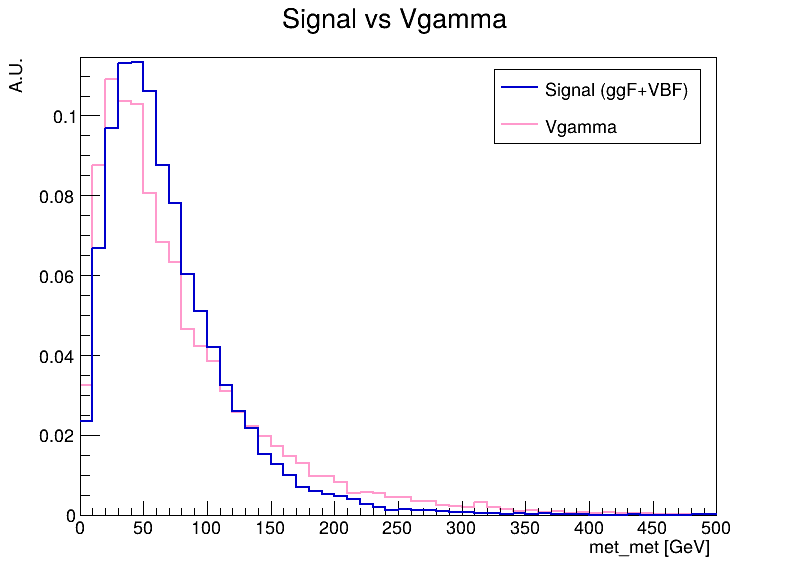

In [6]:
# Open Vgamma background
f_vgamma = ROOT.TFile("PPSSP_2026/1l2tau/run2/Vgamma.root")
t_vgamma = f_vgamma.Get("AnalysisMiniTree")

# Build dataframes
df_sig_vgamma = ROOT.RDataFrame(sig_chain)
df_bkg_vgamma = ROOT.RDataFrame(t_vgamma)

# Apply baseline selection
selection = "n_b_jet == 0 && n_jet >= 2"

df_sig_vgamma = df_sig_vgamma.Filter(selection)
df_bkg_vgamma = df_bkg_vgamma.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_vgamma = df_sig_vgamma.Define("met_met_GeV", "met_met / 1000.")
df_bkg_vgamma = df_bkg_vgamma.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_vgamma_ptr = df_sig_vgamma.Histo1D(("h_sig", "Signal vs Vgamma;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_vgamma_ptr = df_bkg_vgamma.Histo1D(("h_bkg", "Signal vs Vgamma;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_vgamma = h_sig_vgamma_ptr.GetValue()
h_bkg_vgamma = h_bkg_vgamma_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_vgamma.Integral() > 0:
    h_sig_vgamma.Scale(1.0 / h_sig_vgamma.Integral())
if h_bkg_vgamma.Integral() > 0:
    h_bkg_vgamma.Scale(1.0 / h_bkg_vgamma.Integral())

# Draw and save
c = ROOT.TCanvas("c_met_vgamma", "met_met signal vs Vgamma", 800, 600)
h_bkg_vgamma.SetLineColor(ROOT.kPink + 1)
h_bkg_vgamma.SetLineWidth(2)
h_sig_vgamma.SetLineColor(ROOT.kBlue + 1)
h_sig_vgamma.SetLineWidth(2)
h_bkg_vgamma.Draw("hist")
h_sig_vgamma.Draw("hist same")

leg_vgamma = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_vgamma.AddEntry(h_sig_vgamma, "Signal (ggF+VBF)", "l")
leg_vgamma.AddEntry(h_bkg_vgamma, "Vgamma", "l")
leg_vgamma.Draw()

c.SaveAs("met_sig_vs_vgamma.png")
c.Draw()

## VVV Jets 

### Met-Met

Info in <TCanvas::Print>: png file met_sig_vs_vvv.png has been created


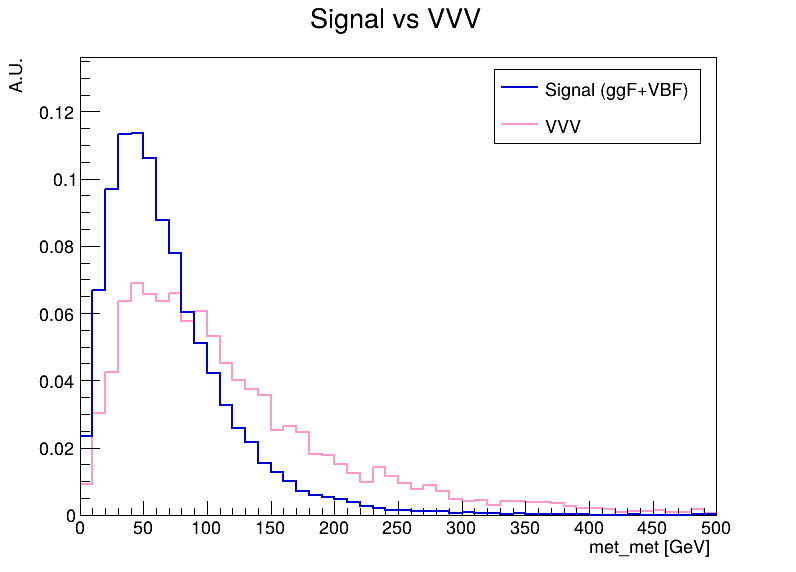

In [7]:
# Open VVV background
f_vvv = ROOT.TFile("PPSSP_2026/1l2tau/run2/VVV.root")
t_vvv = f_vvv.Get("AnalysisMiniTree")

# Build dataframes
df_sig_vvv = ROOT.RDataFrame(sig_chain)
df_bkg_vvv = ROOT.RDataFrame(t_vvv)

# Apply baseline selection
df_sig_vvv = df_sig_vvv.Filter(selection)
df_bkg_vvv = df_bkg_vvv.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_vvv = df_sig_vvv.Define("met_met_GeV", "met_met / 1000.")
df_bkg_vvv = df_bkg_vvv.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_vvv_ptr = df_sig_vvv.Histo1D(("h_sig_vvv", "Signal vs VVV;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_vvv_ptr = df_bkg_vvv.Histo1D(("h_bkg_vvv", "Signal vs VVV;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_vvv = h_sig_vvv_ptr.GetValue()
h_bkg_vvv = h_bkg_vvv_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_vvv.Integral() > 0:
    h_sig_vvv.Scale(1.0 / h_sig_vvv.Integral())
if h_bkg_vvv.Integral() > 0:
    h_bkg_vvv.Scale(1.0 / h_bkg_vvv.Integral())

# Set y-axis maximum with 20% headroom
ymax = max(h_sig_vvv.GetMaximum(), h_bkg_vvv.GetMaximum()) * 1.2
h_bkg_vvv.SetMaximum(ymax)

# Draw and save
c_vvv = ROOT.TCanvas("c_met_vvv", "met_met signal vs VVV", 800, 600)
h_bkg_vvv.SetLineColor(ROOT.kPink + 1)
h_bkg_vvv.SetLineWidth(2)
h_sig_vvv.SetLineColor(ROOT.kBlue + 1)
h_sig_vvv.SetLineWidth(2)
h_bkg_vvv.Draw("hist")
h_sig_vvv.Draw("hist same")

leg_vvv = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_vvv.AddEntry(h_sig_vvv, "Signal (ggF+VBF)", "l")
leg_vvv.AddEntry(h_bkg_vvv, "VVV", "l")
leg_vvv.Draw()

c_vvv.SaveAs("met_sig_vs_vvv.png")
c_vvv.Draw()

## W Jets

### Met-Met Branch

Info in <TCanvas::Print>: png file met_sig_vs_wjets.png has been created


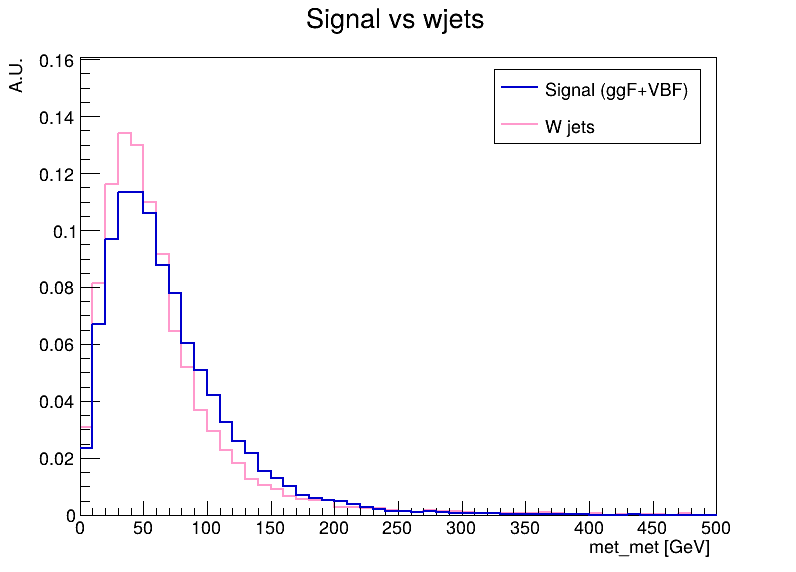

In [8]:
# Open wjets background
f_wjets = ROOT.TFile("PPSSP_2026/1l2tau/run2/Wjets.root")
t_wjets = f_wjets.Get("AnalysisMiniTree")

# Build dataframes
df_sig_wjets = ROOT.RDataFrame(sig_chain)
df_bkg_wjets = ROOT.RDataFrame(t_wjets)

# Apply baseline selection
df_sig_wjets = df_sig_wjets.Filter(selection)
df_bkg_wjets = df_bkg_wjets.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_wjets = df_sig_wjets.Define("met_met_GeV", "met_met / 1000.")
df_bkg_wjets = df_bkg_wjets.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_wjets_ptr = df_sig_wjets.Histo1D(("h_sig_wjets", "Signal vs wjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_wjets_ptr = df_bkg_wjets.Histo1D(("h_bkg_wjets", "Signal vs wjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_wjets = h_sig_wjets_ptr.GetValue()
h_bkg_wjets = h_bkg_wjets_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_wjets.Integral() > 0:
    h_sig_wjets.Scale(1.0 / h_sig_wjets.Integral())
if h_bkg_wjets.Integral() > 0:
    h_bkg_wjets.Scale(1.0 / h_bkg_wjets.Integral())

# Set y-axis maximum with 20% headroom
ymax = max(h_sig_wjets.GetMaximum(), h_bkg_wjets.GetMaximum()) * 1.2
h_bkg_wjets.SetMaximum(ymax)

# Draw and save
c_wjets = ROOT.TCanvas("c_met_wjets", "met_met signal vs wjets", 800, 600)
h_bkg_wjets.SetLineColor(ROOT.kPink + 1)
h_bkg_wjets.SetLineWidth(2)
h_sig_wjets.SetLineColor(ROOT.kBlue + 1)
h_sig_wjets.SetLineWidth(2)
h_bkg_wjets.Draw("hist")
h_sig_wjets.Draw("hist same")

leg_wjets = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_wjets.AddEntry(h_sig_wjets, "Signal (ggF+VBF)", "l")
leg_wjets.AddEntry(h_bkg_wjets, "W jets", "l")
leg_wjets.Draw()

c_wjets.SaveAs("met_sig_vs_wjets.png")
c_wjets.Draw()

## Z Jets

### Met-Met Branch

Info in <TCanvas::Print>: png file met_sig_vs_zjets.png has been created


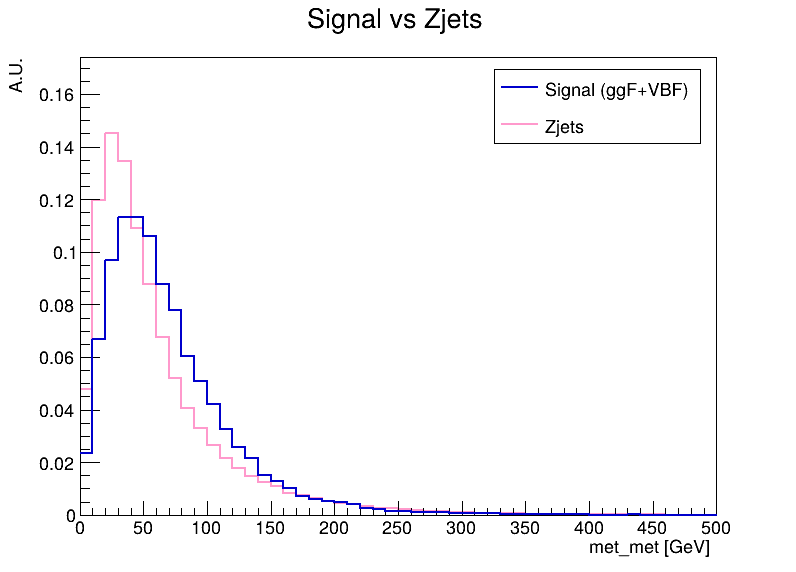

In [9]:
# Open Zjets background
f_zjets = ROOT.TFile("PPSSP_2026/1l2tau/run2/Zjets.root")
t_zjets = f_zjets.Get("AnalysisMiniTree")

# Build dataframes
df_sig_zjets = ROOT.RDataFrame(sig_chain)
df_bkg_zjets = ROOT.RDataFrame(t_zjets)

# Apply baseline selection
df_sig_zjets = df_sig_zjets.Filter(selection)
df_bkg_zjets = df_bkg_zjets.Filter(selection)

# Convert met_met from MeV to GeV
df_sig_zjets = df_sig_zjets.Define("met_met_GeV", "met_met / 1000.")
df_bkg_zjets = df_bkg_zjets.Define("met_met_GeV", "met_met / 1000.")

# Build weighted histograms
h_sig_zjets_ptr = df_sig_zjets.Histo1D(("h_sig_zjets", "Signal vs Zjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")
h_bkg_zjets_ptr = df_bkg_zjets.Histo1D(("h_bkg_zjets", "Signal vs Zjets;met_met [GeV];A.U.", 50, 0, 500), "met_met_GeV", "weight")

# Materialize lazy RDataFrame histograms
h_sig_zjets = h_sig_zjets_ptr.GetValue()
h_bkg_zjets = h_bkg_zjets_ptr.GetValue()

# Normalize to unit area for shape comparison
if h_sig_zjets.Integral() > 0:
    h_sig_zjets.Scale(1.0 / h_sig_zjets.Integral())
if h_bkg_zjets.Integral() > 0:
    h_bkg_zjets.Scale(1.0 / h_bkg_zjets.Integral())

# Set y-axis maximum with 20% headroom
ymax = max(h_sig_zjets.GetMaximum(), h_bkg_zjets.GetMaximum()) * 1.2
h_bkg_zjets.SetMaximum(ymax)

# Draw and save
c_zjets = ROOT.TCanvas("c_met_zjets", "met_met signal vs Zjets", 800, 600)
h_bkg_zjets.SetLineColor(ROOT.kPink + 1)
h_bkg_zjets.SetLineWidth(2)
h_sig_zjets.SetLineColor(ROOT.kBlue + 1)
h_sig_zjets.SetLineWidth(2)
h_bkg_zjets.Draw("hist")
h_sig_zjets.Draw("hist same")

leg_zjets = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
leg_zjets.AddEntry(h_sig_zjets, "Signal (ggF+VBF)", "l")
leg_zjets.AddEntry(h_bkg_zjets, "Zjets", "l")
leg_zjets.Draw()

c_zjets.SaveAs("met_sig_vs_zjets.png")
c_zjets.Draw()

## Met-Met Backgrounds

Info in <TCanvas::Print>: png file met_all_backgrounds.png has been created


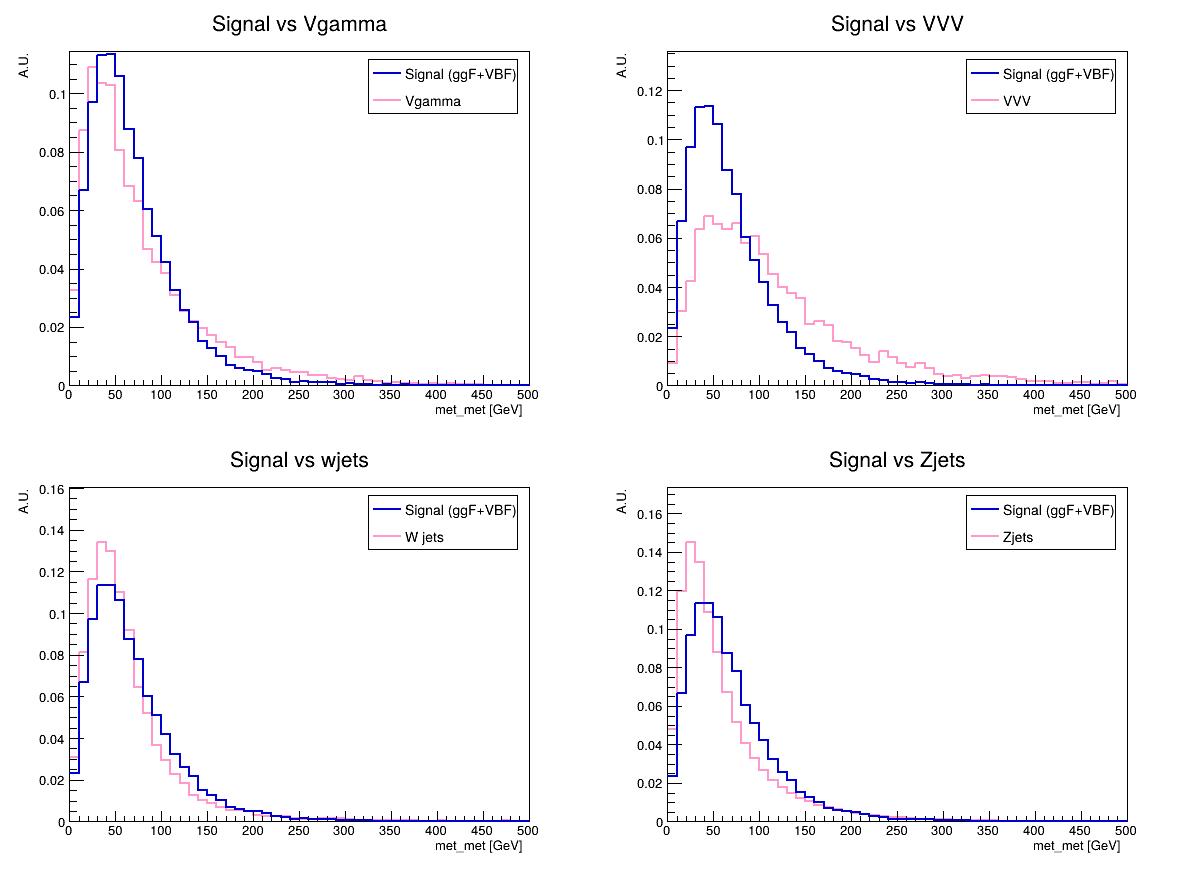

In [10]:
# Create a 2x2 canvas
c_mosaic = ROOT.TCanvas("c_mosaic", "All Met-Met Comparisons", 1200, 900)
c_mosaic.Divide(2, 2)

# Pad 1 (top-left): Vgamma
c_mosaic.cd(1)
h_bkg_vgamma.Draw("hist")
h_sig_vgamma.Draw("hist same")
leg_vgamma.Draw()

# Pad 2 (top-right): VVV
c_mosaic.cd(2)
h_bkg_vvv.Draw("hist")
h_sig_vvv.Draw("hist same")
leg_vvv.Draw()

# Pad 3 (bottom-left): W Jets
c_mosaic.cd(3)
h_bkg_wjets.Draw("hist")
h_sig_wjets.Draw("hist same")
leg_wjets.Draw()

# Pad 4 (bottom-right): Z Jets
c_mosaic.cd(4)
h_bkg_zjets.Draw("hist")
h_sig_zjets.Draw("hist same")
leg_zjets.Draw()

c_mosaic.SaveAs("met_all_backgrounds.png")
c_mosaic.Draw()

In [12]:
import os
import math
from pathlib import Path
ROOT.gStyle.SetOptStat(0)


base_dir = Path("PPSSP_2026/1l2tau/run2")
tree_name = "AnalysisMiniTree"
exclude_files = {"signal_ggF.root", "signal_VBF.root"}

# Background ROOT files only
background_files = sorted([
    p for p in base_dir.glob("*.root")
    if p.name not in exclude_files
])

if not background_files:
    print(f"No background files found in {base_dir}")

# Branches to skip (IDs/flags/weights, etc.)
skip_vars = {"dsid", "eventNumber", "weight"}

# Signal dataframe (apply same selection if available)
df_sig_plot = df_sig.Filter(selection) if "selection" in globals() else df_sig
sig_cols = set(str(name) for name in df_sig_plot.GetColumnNames())

total_saved = 0

for bkg_file in background_files:
    bkg_name = bkg_file.stem
    print(f"\nProcessing background: {bkg_name}")

    f_bkg = ROOT.TFile.Open(str(bkg_file))
    if not f_bkg or f_bkg.IsZombie():
        print(f"  skipping {bkg_name}: cannot open file")
        continue

    t_bkg = f_bkg.Get(tree_name)
    if not t_bkg:
        print(f"  skipping {bkg_name}: missing {tree_name}")
        f_bkg.Close()
        continue

    df_bkg = ROOT.RDataFrame(t_bkg)
    df_bkg_plot = df_bkg.Filter(selection) if "selection" in globals() else df_bkg
    bkg_cols = set(str(name) for name in df_bkg_plot.GetColumnNames())

    common_vars = sorted(sig_cols.intersection(bkg_cols))

    out_dir = Path("plots") / bkg_name
    out_dir.mkdir(parents=True, exist_ok=True)

    saved_for_bkg = 0

    for var in common_vars:
        if var in skip_vars:
            continue

        try:
            sig_min = float(df_sig_plot.Min(var).GetValue())
            sig_max = float(df_sig_plot.Max(var).GetValue())
            bkg_min = float(df_bkg_plot.Min(var).GetValue())
            bkg_max = float(df_bkg_plot.Max(var).GetValue())

            # Skip variables with non-finite ranges (inf/nan)
            if not all(math.isfinite(v) for v in (sig_min, sig_max, bkg_min, bkg_max)):
                continue

            x_min = min(sig_min, bkg_min)
            x_max = max(sig_max, bkg_max)

            # Skip constants / invalid ranges
            if x_min == x_max:
                continue

            # Add small padding so edge values are not clipped on the x-axis
            x_pad = (x_max - x_min) * 0.05
            x_min -= x_pad
            x_max += x_pad

            h_sig_ptr = df_sig_plot.Histo1D(
                (f"h_sig_{bkg_name}_{var}", f"{var};{var};Normalized to unit area", 50, x_min, x_max),
                var,
                "weight",
            )
            h_bkg_ptr = df_bkg_plot.Histo1D(
                (f"h_bkg_{bkg_name}_{var}", f"{var};{var};Normalized to unit area", 50, x_min, x_max),
                var,
                "weight",
            )

            h_sig = h_sig_ptr.GetValue()
            h_bkg = h_bkg_ptr.GetValue()

            sig_int = h_sig.Integral()
            bkg_int = h_bkg.Integral()
            if sig_int <= 0 or bkg_int <= 0:
                continue

            h_sig.Scale(1.0 / sig_int)
            h_bkg.Scale(1.0 / bkg_int)

            c = ROOT.TCanvas(f"c_{bkg_name}_{var}", "", 800, 600)
            # Wider left/bottom margins so the y- and x-axis titles are not clipped
            c.SetLeftMargin(0.16)
            c.SetRightMargin(0.05)
            c.SetBottomMargin(0.14)
            c.SetTopMargin(0.08)

            h_bkg.SetLineColor(ROOT.kPink + 2)
            h_bkg.SetLineWidth(2)
            h_sig.SetLineColor(ROOT.kBlue + 1)
            h_sig.SetLineWidth(2)

            # Push axis titles away from the frame so they sit inside the margins
            h_bkg.GetXaxis().SetTitleOffset(1.2)
            h_bkg.GetYaxis().SetTitleOffset(1.7)
            h_sig.GetXaxis().SetTitleOffset(1.2)
            h_sig.GetYaxis().SetTitleOffset(1.7)

            # Draw the taller histogram first so it owns the axis range,
            # then apply 25% headroom so no peak is clipped at the top frame.
            y_max = max(h_sig.GetMaximum(), h_bkg.GetMaximum()) * 1.25
            if h_sig.GetMaximum() >= h_bkg.GetMaximum():
                h_first, h_second = h_sig, h_bkg
            else:
                h_first, h_second = h_bkg, h_sig

            h_first.SetMinimum(0.0)
            h_first.SetMaximum(y_max)
            h_first.Draw("hist")
            h_second.Draw("hist same")

            leg = ROOT.TLegend(0.62, 0.75, 0.88, 0.88)
            leg.AddEntry(h_sig, "Signal", "l")
            leg.AddEntry(h_bkg, bkg_name, "l")
            leg.Draw()

            safe_var = var.replace("/", "_").replace(" ", "_")
            c.SaveAs(str(out_dir / f"{safe_var}.png"))

            saved_for_bkg += 1
            total_saved += 1

        except Exception as e:
            print(f"  skipping {var}: {e}")

    print(f"  saved {saved_for_bkg} plots in {out_dir}")
    f_bkg.Close()

print(f"\nDone. Total plots saved: {total_saved}")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_HT
Info in <TCanvas::Print>: png file plots/VVV/HT.png has been created



Processing background: VVV


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_HT_all
Info in <TCanvas::Print>: png file plots/VVV/HT_all.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_HT_jet
Info in <TCanvas::Print>: png file plots/VVV/HT_jet.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_HT_lep
Info in <TCanvas::Print>: png file plots/VVV/HT_lep.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_HT_lepMET
Info in <TCanvas::Print>: png file plots/VVV/HT_lepMET.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_HT_tau
Info in <TCanvas::Print>: png file plots/VVV/HT_tau.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_VVV_SumPt_l1j
Info in <TCanvas::Print>: png file plots/VVV/SumPt_l1j.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_V

  saved 96 plots in plots/VVV

Processing background: Vgamma


Info in <TCanvas::Print>: png file plots/Vgamma/HT.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Vgamma_HT_all
Info in <TCanvas::Print>: png file plots/Vgamma/HT_all.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Vgamma_HT_jet
Info in <TCanvas::Print>: png file plots/Vgamma/HT_jet.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Vgamma_HT_lep
Info in <TCanvas::Print>: png file plots/Vgamma/HT_lep.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Vgamma_HT_lepMET
Info in <TCanvas::Print>: png file plots/Vgamma/HT_lepMET.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Vgamma_HT_tau
Info in <TCanvas::Print>: png file plots/Vgamma/HT_tau.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_Vgamma_SumPt_l1j
Info in <TCanvas::Print>: png file plots/

...

  saved 96 plots in plots/singleH

Processing background: tops


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_tops_HT_all
Info in <TCanvas::Print>: png file plots/tops/HT_all.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_tops_HT_jet
Info in <TCanvas::Print>: png file plots/tops/HT_jet.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_tops_HT_lep
Info in <TCanvas::Print>: png file plots/tops/HT_lep.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_tops_HT_lepMET
Info in <TCanvas::Print>: png file plots/tops/HT_lepMET.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_tops_HT_tau
Info in <TCanvas::Print>: png file plots/tops/HT_tau.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_tops_SumPt_l1j
Info in <TCanvas::Print>: png file plots/tops/SumPt_l1j.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with sa

  saved 96 plots in plots/tops

Processing background: ttbar


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ttbar_HT
Info in <TCanvas::Print>: png file plots/ttbar/HT.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ttbar_HT_all
Info in <TCanvas::Print>: png file plots/ttbar/HT_all.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ttbar_HT_jet
Info in <TCanvas::Print>: png file plots/ttbar/HT_jet.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ttbar_HT_lep
Info in <TCanvas::Print>: png file plots/ttbar/HT_lep.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ttbar_HT_lepMET
Info in <TCanvas::Print>: png file plots/ttbar/HT_lepMET.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_ttbar_HT_tau
Info in <TCanvas::Print>: png file plots/ttbar/HT_tau.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same

  saved 96 plots in plots/ttbar

Done. Total plots saved: 768
